# Entraînement TabM — prévision des rafales de vent

Notebook Google Colab complet pour entraîner et évaluer **TabM** sur la cible
`has_gust`.

Découpage chronologique :

- entraînement : 2021–2023 ;
- validation : 2024 (arrêt anticipé et choix du seuil) ;
- test final : 2025.

## 1. Installation

In [ ]:
!pip -q install "tabm==0.0.3" "rtdl-num-embeddings" pyarrow scikit-learn joblib tqdm

## 2. Imports et configuration

In [ ]:
import os
import json
import random
import time
import zipfile
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm

from tabm import TabM
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

SEED = 42
TARGET = "has_gust"
DATE_COLUMN = "datetime"

# Paramètres adaptés à Colab. En cas de mémoire insuffisante, réduire BATCH_SIZE.
BATCH_SIZE = 1024
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

# Modèle plus léger que les valeurs par défaut pour accélérer Colab.
TABM_K = 16
D_BLOCK = 256
N_BLOCKS = 3
DROPOUT = 0.10

# Mettre True pour vérifier rapidement le notebook avant l'entraînement complet.
QUICK_TEST = False
MAX_ROWS_PER_SPLIT = 50_000

OUTPUT_DIR = Path("resultats_tabm")
OUTPUT_DIR.mkdir(exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"

print("PyTorch :", torch.__version__)
print("Appareil utilisé :", device)
if device.type == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("ATTENTION : activez un GPU T4 dans les paramètres Colab.")

PyTorch : 2.11.0+cu128
Appareil utilisé : cuda
GPU : Tesla T4


## 3. Charger le dataset

La cellule suivante accepte un fichier `.parquet` ou `.csv`.
Pour un gros fichier, Google Drive est souvent plus stable que le téléversement direct.

In [ ]:
# Option A — téléversement direct depuis l'ordinateur.
from google.colab import files

uploaded = files.upload()
if not uploaded:
    raise RuntimeError("Aucun fichier téléversé.")

DATASET_PATH = Path(next(iter(uploaded.keys())))
print("Fichier sélectionné :", DATASET_PATH)

Saving Dataset_features.parquet to Dataset_features.parquet
Fichier sélectionné : Dataset_features.parquet


In [ ]:
def load_dataset(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    print("Début de la lecture...")
    start = time.time()

    if suffix in {".parquet", ".pq"}:
        frame = pd.read_parquet(path)
    elif suffix in {".csv", ".txt"}:
        try:
            frame = pd.read_csv(path, low_memory=False)
        except UnicodeDecodeError:
            frame = pd.read_csv(path, encoding="latin-1", low_memory=False)
    else:
        raise ValueError("Le fichier doit être au format CSV ou Parquet.")

    print(f"Lecture terminée en {time.time() - start:.1f} s : {frame.shape}")
    return frame


df = load_dataset(DATASET_PATH)
display(df.head())
print("Colonnes disponibles :")
print(df.columns.tolist())

Début de la lecture...
Lecture terminée en 0.5 s : (808914, 26)


,datetime,icao,year,lon,lat,u10,v10,t2m,rh2m,u850,...,tke20m,edr20m,pblh,distance_km,elevation_m,hour_sin,hour_cos,doy_sin,doy_cos,has_gust
0,2021-01-01,GMML,2021,-13.200,27.150,-0.375698,-2.860277,286.744537,0.758287,-0.529859,...,0.000001,0.000001,10.0,0.0,63.09,0.0,1.0,0.017202,0.999852,0
1,2021-01-01,GMMF,2021,-10.175,29.350,-1.258511,2.202223,285.141998,0.971666,0.845141,...,0.000001,0.000001,10.0,0.0,59.00,0.0,1.0,0.017202,0.999852,0
2,2021-01-01,GSVO,2021,-15.850,23.700,-3.117886,-5.829027,290.837311,0.849107,-1.998609,...,0.000001,0.000001,10.0,0.0,10.00,0.0,1.0,0.017202,0.999852,0
3,2021-01-01,GMTT,2021,-5.900,35.725,1.171177,7.928785,281.795319,0.790758,16.142016,...,0.000001,0.000001,10.0,0.0,18.89,0.0,1.0,0.017202,0.999852,0
4,2021-01-01,GMTA,2021,-3.850,35.175,0.593052,2.686598,281.710358,0.511949,12.251391,...,0.000001,0.000001,10.0,0.0,27.12,0.0,1.0,0.017202,0.999852,0


Colonnes disponibles :
['datetime', 'icao', 'year', 'lon', 'lat', 'u10', 'v10', 't2m', 'rh2m', 'u850', 'v850', 'u950', 'v950', 'psurf', 'u_gust60', 'v_gust60', 'tke20m', 'edr20m', 'pblh', 'distance_km', 'elevation_m', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'has_gust']


## 4. Préparation des variables

Le notebook conserve uniquement les variables AROME et géographiques. Les observations
METAR susceptibles de révéler la cible ne sont pas utilisées comme prédicteurs.

In [ ]:
if TARGET not in df.columns:
    raise ValueError(f"Colonne cible absente : {TARGET}")
if DATE_COLUMN not in df.columns:
    raise ValueError(f"Colonne temporelle absente : {DATE_COLUMN}")

# Uniformiser les noms des coordonnées sans créer de doublons.
if "lat" not in df.columns and "latitude" in df.columns:
    df = df.rename(columns={"latitude": "lat"})
if "lon" not in df.columns and "longitude" in df.columns:
    df = df.rename(columns={"longitude": "lon"})

df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors="coerce")
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df.dropna(subset=[DATE_COLUMN, TARGET]).copy()
df[TARGET] = df[TARGET].astype("int8")

invalid_targets = sorted(set(df[TARGET].unique()) - {0, 1})
if invalid_targets:
    raise ValueError(f"La cible doit contenir seulement 0 et 1 : {invalid_targets}")


df["hour"] = df[DATE_COLUMN].dt.hour
df["day_of_year"] = df[DATE_COLUMN].dt.dayofyear

candidate_features = [
    "u10", "v10", "t2m", "rh2m",
    "u850", "v850", "u950", "v950", "psurf",
    "u_gust60", "v_gust60", "tke20m", "edr20m", "pblh",
    "lat", "lon", "elevation_m", "distance_km",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
]

features = [column for column in candidate_features if column in df.columns]
missing_features = [column for column in candidate_features if column not in df.columns]

if not features:
    raise ValueError("Aucune variable d'entrée attendue n'est disponible.")

for column in features:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print(f"{len(features)} variables utilisées :", features)
print("Variables optionnelles absentes :", missing_features)
print("Années disponibles :", sorted(df["year"].unique().tolist()))
print("Nombre de valeurs manquantes par variable :")
display(df[features].isna().sum().sort_values(ascending=False).to_frame("manquants"))

22 variables utilisées : ['u10', 'v10', 't2m', 'rh2m', 'u850', 'v850', 'u950', 'v950', 'psurf', 'u_gust60', 'v_gust60', 'tke20m', 'edr20m', 'pblh', 'lat', 'lon', 'elevation_m', 'distance_km', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
Variables optionnelles absentes : []
Années disponibles : [2021, 2022, 2023, 2024, 2025]
Nombre de valeurs manquantes par variable :


,manquants
elevation_m,24311
u10,0
t2m,0
rh2m,0
u850,0
v10,0
v850,0
u950,0
psurf,0
v950,0


## 5. Split chronologique

In [ ]:
train_df = df[df["year"].between(2021, 2023)].copy()
validation_df = df[df["year"] == 2024].copy()
test_df = df[df["year"] == 2025].copy()

for split_name, split_df in {
    "train 2021–2023": train_df,
    "validation 2024": validation_df,
    "test 2025": test_df,
}.items():
    if split_df.empty:
        raise ValueError(f"Le split {split_name} est vide. Vérifiez les dates du dataset.")

if QUICK_TEST:
    def limit_split(frame):
        n = min(MAX_ROWS_PER_SPLIT, len(frame))
        return frame.sample(n=n, random_state=SEED).sort_values(DATE_COLUMN)

    train_df = limit_split(train_df)
    validation_df = limit_split(validation_df)
    test_df = limit_split(test_df)
    print("MODE TEST RAPIDE ACTIVÉ")

summary_rows = []
for name, part in [
    ("Train 2021–2023", train_df),
    ("Validation 2024", validation_df),
    ("Test 2025", test_df),
]:
    summary_rows.append({
        "split": name,
        "lignes": len(part),
        "rafales": int(part[TARGET].sum()),
        "sans_rafale": int((part[TARGET] == 0).sum()),
        "taux_rafales": float(part[TARGET].mean()),
    })

split_summary = pd.DataFrame(summary_rows)
display(split_summary)

# Libérer le grand DataFrame original avant les transformations.
del df

,split,lignes,rafales,sans_rafale,taux_rafales
0,Train 2021–2023,491053,14150,476903,0.028816
1,Validation 2024,196441,5726,190715,0.029149
2,Test 2025,121420,4452,116968,0.036666


## 6. Imputation et standardisation

L'imputer et le scaler sont ajustés uniquement sur 2021–2023 afin d'éviter la fuite
de données.

In [ ]:
print("Début de l'imputation...")
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train = imputer.fit_transform(train_df[features])
X_validation = imputer.transform(validation_df[features])
X_test = imputer.transform(test_df[features])

print("Début de la standardisation...")
X_train = scaler.fit_transform(X_train).astype("float32")
X_validation = scaler.transform(X_validation).astype("float32")
X_test = scaler.transform(X_test).astype("float32")

y_train = train_df[TARGET].to_numpy(dtype="float32")
y_validation = validation_df[TARGET].to_numpy(dtype="float32")
y_test = test_df[TARGET].to_numpy(dtype="float32")

joblib.dump(
    {"imputer": imputer, "scaler": scaler, "features": features},
    OUTPUT_DIR / "preprocessor_tabm.joblib",
)

print("Prétraitement terminé.")
print("X_train :", X_train.shape, "| X_validation :", X_validation.shape, "| X_test :", X_test.shape)

Début de l'imputation...
Début de la standardisation...
Prétraitement terminé.
X_train : (491053, 22) | X_validation : (196441, 22) | X_test : (121420, 22)


## 7. DataLoaders PyTorch

In [ ]:
def make_loader(X, y, shuffle=False):
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )


train_loader = make_loader(X_train, y_train, shuffle=True)
validation_loader = make_loader(X_validation, y_validation)
test_loader = make_loader(X_test, y_test)

print("Batches train :", len(train_loader))
print("Batches validation :", len(validation_loader))
print("Batches test :", len(test_loader))

Batches train : 480
Batches validation : 192
Batches test : 119


## 8. Création de TabM

In [ ]:
model = TabM.make(
    n_num_features=len(features),
    cat_cardinalities=[],
    d_out=1,
    arch_type="tabm",
    k=TABM_K,
    d_block=D_BLOCK,
    n_blocks=N_BLOCKS,
    dropout=DROPOUT,
).to(device)

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
if positive_count == 0:
    raise ValueError("Aucune rafale (classe 1) dans le jeu d'entraînement.")

scale_pos_weight = negative_count / positive_count
pos_weight = torch.tensor([scale_pos_weight], dtype=torch.float32, device=device)
loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)
scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)

parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Paramètres entraînables : {parameter_count:,}")
print(f"scale_pos_weight : {scale_pos_weight:.4f}")

TabM(
  (ensemble_view): EnsembleView()
  (backbone): MLPBackboneBatchEnsemble(
    (blocks): ModuleList(
      (0-2): 3 x Sequential(
        (0): LinearBatchEnsemble()
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output): LinearEnsemble()
)
Paramètres entraînables : 173,936
scale_pos_weight : 33.7034


/tmp/ipykernel_3283/743523942.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)


## 9. Fonctions d'entraînement et de prédiction

In [ ]:
@torch.inference_mode()
def predict_probabilities(loader, description="Prédiction"):
    model.eval()
    all_probabilities = []
    all_targets = []

    for X_batch, y_batch in tqdm(loader, desc=description, leave=False):
        X_batch = X_batch.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(X_batch).squeeze(-1)       # (batch, k)
            probabilities = torch.sigmoid(logits).mean(dim=1)

        all_probabilities.append(probabilities.cpu().numpy())
        all_targets.append(y_batch.numpy())

    return np.concatenate(all_probabilities), np.concatenate(all_targets).astype(int)


def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    seen = 0
    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS}")

    for X_batch, y_batch in progress:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(X_batch).squeeze(-1)       # (batch, k)
            targets = y_batch[:, None].expand_as(logits)
            # Important : perte sur chaque membre TabM, puis moyenne.
            loss = loss_function(logits, targets)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        batch_size = X_batch.size(0)
        running_loss += loss.item() * batch_size
        seen += batch_size
        progress.set_postfix(loss=f"{running_loss / seen:.5f}")

    return running_loss / seen

## 10. Entraînement avec validation et arrêt anticipé

In [ ]:
best_pr_auc = -np.inf
best_epoch = 0
epochs_without_improvement = 0
history = []
checkpoint_path = OUTPUT_DIR / "modele_tabm.pt"

print("Début de l'entraînement TabM...")
training_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.time()
    train_loss = train_one_epoch(epoch)
    validation_probabilities, validation_targets = predict_probabilities(
        validation_loader, "Validation"
    )
    validation_pr_auc = average_precision_score(
        validation_targets, validation_probabilities
    )
    scheduler.step(validation_pr_auc)

    epoch_seconds = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]["lr"]
    history.append({
        "epoch": epoch,
        "train_loss": float(train_loss),
        "validation_pr_auc": float(validation_pr_auc),
        "learning_rate": float(current_lr),
        "seconds": float(epoch_seconds),
    })

    print(
        f"Fin epoch {epoch:02d} | loss={train_loss:.5f} | "
        f"PR-AUC val={validation_pr_auc:.5f} | lr={current_lr:.2e} | "
        f"temps={epoch_seconds:.1f}s"
    )

    if validation_pr_auc > best_pr_auc + 1e-5:
        best_pr_auc = validation_pr_auc
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "features": features,
                "threshold": None,
                "model_config": {
                    "arch_type": "tabm",
                    "k": TABM_K,
                    "d_block": D_BLOCK,
                    "n_blocks": N_BLOCKS,
                    "dropout": DROPOUT,
                    "n_num_features": len(features),
                },
                "best_epoch": best_epoch,
                "validation_pr_auc": float(best_pr_auc),
            },
            checkpoint_path,
        )
        print("  → Nouveau meilleur modèle sauvegardé.")
    else:
        epochs_without_improvement += 1
        print(f"  → Sans amélioration : {epochs_without_improvement}/{PATIENCE}")

    if epochs_without_improvement >= PATIENCE:
        print("Arrêt anticipé.")
        break

training_seconds = time.time() - training_start
pd.DataFrame(history).to_csv(OUTPUT_DIR / "historique_entrainement.csv", index=False)
print(f"Entraînement terminé en {training_seconds / 60:.1f} min.")
print("Meilleure epoch :", best_epoch, "| meilleure PR-AUC validation :", best_pr_auc)

Début de l'entraînement TabM...


Epoch 1/30:   0%|          | 0/480 [00:00<?, ?it/s]

/tmp/ipykernel_3283/2812974092.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Validation:   0%|          | 0/192 [00:00<?, ?it/s]

/tmp/ipykernel_3283/2812974092.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

Epoch 21/30:   0%|          | 0/480 [00:00<?, ?it/s]

/tmp/ipykernel_3283/2812974092.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Validation:   0%|          | 0/192 [00:00<?, ?it/s]

/tmp/ipykernel_3283/2812974092.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Fin epoch 21 | loss=0.47289 | PR-AUC val=0.39972 | lr=1.00e-03 | temps=10.1s
  → Sans amélioration : 5/5
Arrêt anticipé.
Entraînement terminé en 3.3 min.
Meilleure epoch : 16 | meilleure PR-AUC validation : 0.4072099836591413


## 11. Meilleur seuil sur la validation 2024

In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])

validation_probabilities, validation_targets = predict_probabilities(
    validation_loader, "Validation finale"
)
precision_curve, recall_curve, thresholds = precision_recall_curve(
    validation_targets, validation_probabilities
)

f1_curve = (
    2 * precision_curve[:-1] * recall_curve[:-1]
    / (precision_curve[:-1] + recall_curve[:-1] + 1e-12)
)
best_threshold_index = int(np.argmax(f1_curve))
best_threshold = float(thresholds[best_threshold_index])
validation_predictions = (validation_probabilities >= best_threshold).astype(int)

print(f"Meilleur seuil : {best_threshold:.6f}")
print(f"Precision validation : {precision_curve[best_threshold_index]:.4f}")
print(f"Recall validation : {recall_curve[best_threshold_index]:.4f}")
print(f"F1 validation : {f1_curve[best_threshold_index]:.4f}")
print(f"PR-AUC validation : {average_precision_score(validation_targets, validation_probabilities):.4f}")
print("\nRapport validation 2024 :")
print(classification_report(validation_targets, validation_predictions, digits=4, zero_division=0))

# Réenregistrer le seuil dans le checkpoint final.
checkpoint["threshold"] = best_threshold
torch.save(checkpoint, checkpoint_path)

Validation finale:   0%|          | 0/192 [00:00<?, ?it/s]

/tmp/ipykernel_3283/2812974092.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Meilleur seuil : 0.903901
Precision validation : 0.5473
Recall validation : 0.3954
F1 validation : 0.4591
PR-AUC validation : 0.4072

Rapport validation 2024 :
              precision    recall  f1-score   support

           0     0.9820    0.9902    0.9861    190715
           1     0.5473    0.3954    0.4591      5726

    accuracy                         0.9728    196441
   macro avg     0.7646    0.6928    0.7226    196441
weighted avg     0.9693    0.9728    0.9707    196441



## 12. Évaluation finale sur 2025

In [ ]:
test_probabilities, test_targets = predict_probabilities(test_loader, "Test 2025")
test_predictions = (test_probabilities >= best_threshold).astype(int)

test_metrics = {
    "accuracy": float(accuracy_score(test_targets, test_predictions)),
    "precision": float(precision_score(test_targets, test_predictions, zero_division=0)),
    "recall": float(recall_score(test_targets, test_predictions, zero_division=0)),
    "f1_score": float(f1_score(test_targets, test_predictions, zero_division=0)),
    "pr_auc": float(average_precision_score(test_targets, test_probabilities)),
    "roc_auc": float(roc_auc_score(test_targets, test_probabilities)),
}

validation_metrics = {
    "pr_auc": float(average_precision_score(validation_targets, validation_probabilities)),
    "threshold": best_threshold,
    "precision": float(precision_score(validation_targets, validation_predictions, zero_division=0)),
    "recall": float(recall_score(validation_targets, validation_predictions, zero_division=0)),
    "f1_score": float(f1_score(validation_targets, validation_predictions, zero_division=0)),
}

all_metrics = {
    "model": "TabM",
    "split": {"train": "2021-2023", "validation": 2024, "test": 2025},
    "features": features,
    "scale_pos_weight": float(scale_pos_weight),
    "best_epoch": int(best_epoch),
    "training_seconds": float(training_seconds),
    "validation": validation_metrics,
    "test": test_metrics,
    "classification_report_test": classification_report(
        test_targets, test_predictions, output_dict=True, zero_division=0
    ),
}

print("TEST FINAL 2025")
print(json.dumps(test_metrics, indent=2, ensure_ascii=False))
print("\nRapport de classification :")
print(classification_report(test_targets, test_predictions, digits=4, zero_division=0))
print("Matrice de confusion :\n", confusion_matrix(test_targets, test_predictions))

with open(OUTPUT_DIR / "metrics_tabm.json", "w", encoding="utf-8") as file:
    json.dump(all_metrics, file, indent=2, ensure_ascii=False)

Test 2025:   0%|          | 0/119 [00:00<?, ?it/s]

/tmp/ipykernel_3283/2812974092.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


TEST FINAL 2025
{
  "accuracy": 0.9609454785043651,
  "precision": 0.4526143790849673,
  "recall": 0.3110961365678347,
  "f1_score": 0.3687433439829606,
  "pr_auc": 0.3153059364818185,
  "roc_auc": 0.7539383539783544
}

Rapport de classification :
              precision    recall  f1-score   support

           0     0.9741    0.9857    0.9798    116968
           1     0.4526    0.3111    0.3687      4452

    accuracy                         0.9609    121420
   macro avg     0.7134    0.6484    0.6743    121420
weighted avg     0.9550    0.9609    0.9574    121420

Matrice de confusion :
 [[115293   1675]
 [  3067   1385]]


## 13. Sauvegarder les prédictions et les graphiques

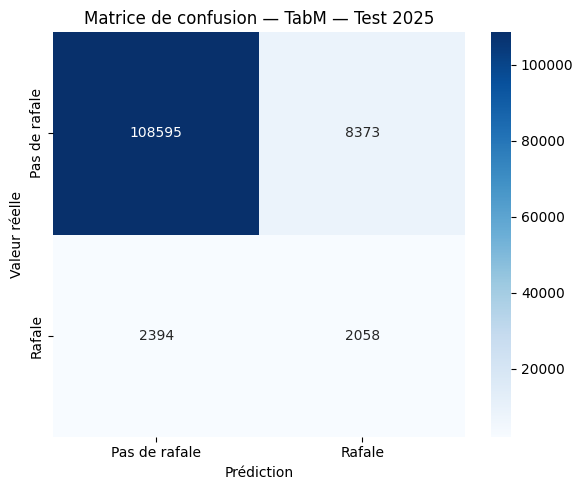

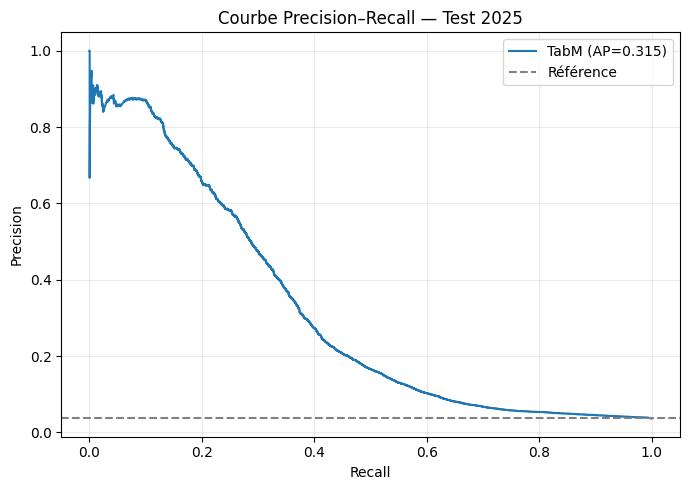

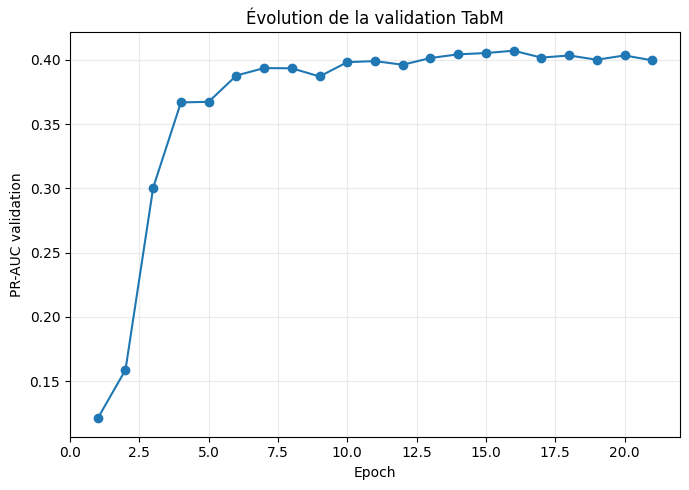

In [ ]:
identifier_columns = [
    column for column in ["icao", "station", "indicatif", DATE_COLUMN, TARGET]
    if column in test_df.columns
]
predictions_df = test_df[identifier_columns].copy()
predictions_df["prediction"] = test_predictions
predictions_df["probabilite_has_gust"] = test_probabilities
predictions_df.to_csv(OUTPUT_DIR / "predictions_tabm_2025.csv", index=False)

cm = confusion_matrix(test_targets, test_predictions, labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pas de rafale", "Rafale"],
    yticklabels=["Pas de rafale", "Rafale"],
)
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion — TabM — Test 2025")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matrice_confusion_tabm_2025.png", dpi=180)
plt.show()

test_precision_curve, test_recall_curve, _ = precision_recall_curve(
    test_targets, test_probabilities
)
plt.figure(figsize=(7, 5))
plt.plot(test_recall_curve, test_precision_curve, label=f"TabM (AP={test_metrics['pr_auc']:.3f})")
plt.axhline(test_targets.mean(), linestyle="--", color="gray", label="Référence")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision–Recall — Test 2025")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "courbe_precision_recall_tabm_2025.png", dpi=180)
plt.show()

history_df = pd.DataFrame(history)
plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["validation_pr_auc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC validation")
plt.title("Évolution de la validation TabM")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "historique_validation_tabm.png", dpi=180)
plt.show()

## 14. Télécharger tous les résultats

In [ ]:
archive_path = Path("resultats_tabm.zip")
with zipfile.ZipFile(archive_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for path in OUTPUT_DIR.iterdir():
        archive.write(path, arcname=path.name)

print("Fichiers créés :")
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)
print("-", archive_path.name)

files.download(str(archive_path))

## Résultats obtenus

L'archive contient :

- `modele_tabm.pt` : poids, configuration, liste des variables et seuil ;
- `preprocessor_tabm.joblib` : imputer et standardisation ;
- `metrics_tabm.json` : métriques de validation et de test ;
- `predictions_tabm_2025.csv` : probabilités et classes prédites ;
- les courbes et la matrice de confusion ;
- `historique_entrainement.csv`.